In [1]:
# Keras machine learning for T1D

In [1]:
#import pyreadr
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import itertools as it
import pandas as pd
from pandas.plotting import scatter_matrix
import scipy
import numpy as np
import xgboost
from catboost import CatBoostClassifier

In [2]:
from sklearn.preprocessing import LabelBinarizer
from sklearn.metrics import classification_report
import matplotlib.pyplot as plt
import numpy as np
import argparse

In [3]:
import sklearn
import seaborn as sns
import scipy
from sklearn import svm
from sklearn.metrics import RocCurveDisplay, auc
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import roc_curve, auc, RocCurveDisplay


In [4]:
from scipy.stats import mannwhitneyu
from scipy import stats
from sklearn import metrics
import statsmodels.formula.api as smf
import statsmodels.api as sm

In [5]:
from pandas import read_csv
from sklearn.model_selection import cross_val_score
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn import preprocessing
import warnings
warnings.filterwarnings('ignore')

In [38]:
T1df=pd.read_csv("/cellar/users/tsears/projects/T1D/ALL5_199_TOPMED_SUSIE_HLA_T1D_signals_updateID.vcf",sep="\t",skiprows=27)

In [39]:
T1df.index=T1df["ID"]
T1df=T1df.drop(["#CHROM","POS","ID","REF","ALT","QUAL","FILTER","INFO","FORMAT"],axis=1)
T1df.columns=[x.split("_",2)[2] for x in T1df.columns]
T1df=np.transpose(T1df)
T1df

ID,chr1:24968387:T:C,chr1:35571621:A:G,chr1:37880724:C:T,chr1:63648218:T:C,chr1:113834946:A:G,chr1:119962909:G:A,chr1:192541882:G:C,chr1:198654713:G:T,chr1:200863456:A:G,chr1:206770623:C:A,...,chr18:69859408:T:C,chr19:10352442:G:C,chr19:18522945:T:C,chr19:46715865:T:C,chr19:48703417:G:A,chr20:1629416:A:C,chr21:42403617:C:G,chr21:44294411:C:T,chr22:30171918:C:G,chr22:37185445:C:A
CAGS_600004963801,1/1,0/0,1/1,0/0,1/1,0/1,1/1,0/0,0/1,0/0,...,0/1,0/0,0/0,0/0,0/0,1/1,0/1,0/0,0/0,1/1
CAGS_600020689310,0/1,0/0,0/1,0/0,1/1,0/0,0/1,0/1,0/0,0/0,...,0/1,0/0,0/1,0/0,0/1,1/1,0/0,0/0,0/0,1/1
CAGS_600027602842,1/1,0/0,0/0,0/0,0/1,1/1,1/1,0/0,0/0,0/0,...,0/1,0/0,0/0,0/0,0/1,1/1,0/1,0/0,0/1,0/1
CAGS_600039665619,0/0,0/0,0/1,0/0,1/1,0/0,1/1,0/0,0/0,0/0,...,0/1,0/0,0/1,0/0,1/1,0/0,0/0,0/0,0/1,0/1
CAGS_600041559013,1/1,0/0,0/1,0/0,1/1,0/1,0/1,0/0,0/1,0/0,...,1/1,0/0,1/1,0/0,0/1,0/0,0/1,0/0,1/1,0/1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
WTCCC2-NBS-I_WTCCCT511842,0/1,0/0,0/1,0/1,1/1,0/0,1/1,0/1,0/1,0/0,...,0/1,0/1,0/1,0/1,1/1,0/0,0/0,0/0,0/1,0/0
WTCCC2-NBS-I_WTCCCT511844,0/1,0/0,0/1,0/0,1/1,0/0,0/1,0/0,0/0,0/1,...,0/1,0/0,0/0,0/0,0/1,0/0,0/0,0/0,0/0,0/1
WTCCC2-NBS-I_WTCCCT511846,0/1,0/0,0/1,0/1,1/1,0/1,1/1,0/0,0/0,0/0,...,0/1,0/0,0/1,0/1,0/0,0/1,0/0,0/0,0/0,0/1
WTCCC2-NBS-I_WTCCCT511847,0/1,0/0,0/0,0/1,1/1,0/0,0/1,0/0,0/0,0/0,...,1/1,0/1,0/0,0/1,0/1,1/1,0/0,0/0,0/0,1/1


In [40]:
# read in metadata
meta=pd.read_csv("/cellar/users/tsears/projects/T1D/meta_all5_cat_cov.ped",sep=" ")
meta

,#FID,IID,SEX,DISEASE,PC1,PC2,PC3,PC4,T1DGC,DCCT,GENIE_UK,GoKIND
0,T1DGC-I_T1DGC-2,T1DGC-I_T1DGC-2,2,2,0.001178,0.015571,0.019469,-0.006189,1,0,0,0
1,T1DGC-I_T1DGC-3,T1DGC-I_T1DGC-3,2,2,-0.001387,-0.022562,-0.012227,0.018424,1,0,0,0
2,T1DGC-I_T1DGC-4,T1DGC-I_T1DGC-4,2,2,-0.014290,-0.003476,-0.008878,0.012580,1,0,0,0
3,T1DGC-I_T1DGC-5,T1DGC-I_T1DGC-5,2,2,-0.006064,0.002590,-0.004332,0.010348,1,0,0,0
4,T1DGC-I_T1DGC-6,T1DGC-I_T1DGC-6,2,2,0.022466,0.007408,-0.010029,0.015746,1,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...
29741,WTCCC1-T1D-A_WTCCC184920,WTCCC1-T1D-A_WTCCC184920,2,2,0.003835,-0.005961,-0.005418,0.011956,0,0,0,0
29742,WTCCC1-T1D-A_WTCCC184921,WTCCC1-T1D-A_WTCCC184921,1,2,-0.002208,-0.008881,0.019262,-0.114337,0,0,0,0
29743,WTCCC1-T1D-A_WTCCC184922,WTCCC1-T1D-A_WTCCC184922,1,2,-0.000697,0.005810,0.004484,-0.012091,0,0,0,0
29744,WTCCC1-T1D-A_WTCCC184925,WTCCC1-T1D-A_WTCCC184925,1,2,-0.000352,0.007940,0.009637,-0.008510,0,0,0,0


In [41]:
# merge datasets
meta_T1df=pd.merge(T1df,meta,left_index=True,right_on="#FID")
meta_T1df.index=meta_T1df["#FID"]
meta_T1df["GENIEUK"]=meta_T1df["GENIE_UK"]
meta_T1df=meta_T1df.drop(["#FID","IID","GENIE_UK"],axis=1)

In [42]:
#Map 0/0 stuff to snps 
cols2map=[x for x in list(meta_T1df.columns) if 'chr' in x]
cols2map2=[x for x in list(meta_T1df.columns) if 'rs' in x]
cols2map3=[x for x in list(meta_T1df.columns) if '_' in x]
#cols2map3=[x for x in list(meta_T1df.columns) if 'chr' in x]
cols2map_all=cols2map+cols2map2+cols2map3

for col in cols2map_all:
    meta_T1df[col]=meta_T1df[col].map({"0/0":0,"0/1":1,"1/0":1,"1/1":2})
    
meta_T1df

,chr1:24968387:T:C,chr1:35571621:A:G,chr1:37880724:C:T,chr1:63648218:T:C,chr1:113834946:A:G,chr1:119962909:G:A,chr1:192541882:G:C,chr1:198654713:G:T,chr1:200863456:A:G,chr1:206770623:C:A,...,SEX,DISEASE,PC1,PC2,PC3,PC4,T1DGC,DCCT,GoKIND,GENIEUK
#FID,,,,,,,,,,,,,,,,,,,,,
CAGS_600004963801,2,0,2,0,2,1,2,0,1,0,...,2,1,0.059879,0.010268,0.036651,0.006898,0,1,0,0
CAGS_600020689310,1,0,1,0,2,0,1,1,0,0,...,2,1,0.002826,-0.001928,0.003484,-0.012642,0,1,0,0
CAGS_600027602842,2,0,0,0,1,2,2,0,0,0,...,2,1,0.003038,0.006339,-0.009819,-0.012894,0,1,0,0
CAGS_600039665619,0,0,1,0,2,0,2,0,0,0,...,1,1,0.012467,-0.000298,-0.022340,-0.001515,0,1,0,0
CAGS_600041559013,2,0,1,0,2,1,1,0,1,0,...,2,1,-0.005966,-0.016528,0.004837,-0.017514,0,1,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
WTCCC2-NBS-I_WTCCCT511842,1,0,1,1,2,0,2,1,1,0,...,2,1,0.005411,-0.006333,-0.017118,-0.000367,1,0,0,0
WTCCC2-NBS-I_WTCCCT511844,1,0,1,0,2,0,1,0,0,1,...,1,1,0.015640,0.012072,-0.009146,-0.019781,1,0,0,0
WTCCC2-NBS-I_WTCCCT511846,1,0,1,1,2,1,2,0,0,0,...,1,1,-0.000938,-0.001460,-0.002516,-0.005791,1,0,0,0


In [43]:
meta_T1df.to_csv('/cellar/users/tsears/projects/T1D/formattedVCF.txt',sep='\t')

In [44]:
meta_T1df['GENIEUK'].value_counts()

0    23089
1     6657
Name: GENIEUK, dtype: int64

In [47]:
meta_T1df_dropped=meta_T1df#[meta_T1df["GENIEUK"]==0]
meta_T1df_dropped.shape[0]

meta_T1df_dropped_nonHLA=meta_T1df_dropped.filter(regex="chr")
meta_T1df_dropped_HLA=meta_T1df_dropped.loc[:,list(~meta_T1df_dropped.columns.isin(meta_T1df_dropped_nonHLA.columns))]

meta_T1df_dropped_HLA=meta_T1df_dropped_HLA.drop(['SEX',
 'T1DGC',
 'DCCT',
 'GoKIND',"PC1","PC2","PC3","PC4",
 'GENIEUK'],axis=1)

meta_T1df_dropped=meta_T1df_dropped.drop(['SEX',
 'T1DGC',
 'DCCT',
 'GoKIND',"PC1","PC2","PC3","PC4",
 'GENIEUK'],axis=1)

#meta_T1df_dropped.iloc[:5,:].to_csv("/cellar/users/tsears/projects/T1D/SampleVCFs/ALL.txt",sep="\t")
#meta_T1df_dropped_HLA.iloc[:5,:].to_csv("/cellar/users/tsears/projects/T1D/SampleVCFs/HLA.txt",sep="\t")
#meta_T1df_dropped_nonHLA.iloc[:5,:].to_csv("/cellar/users/tsears/projects/T1D/SampleVCFs/nonHLA.txt",sep="\t")

testing_df=meta_T1df_dropped["DISEASE"]
training_df=meta_T1df_dropped.drop(["DISEASE"],axis=1)


In [ ]:
# read in links table, trim down to innate genes only
# 



Fold 0 AUC: 0.9385109014687723
Fold 1 AUC: 0.946728048493053
Fold 2 AUC: 0.9358844966065742
Fold 3 AUC: 0.9325560383641451
Fold 4 AUC: 0.9368348371578623
Fold 5 AUC: 0.9340452577653955
Fold 6 AUC: 0.9334758323082818
Fold 7 AUC: 0.9285676836522756
Fold 8 AUC: 0.9473104998890928
Fold 9 AUC: 0.9326597443405271


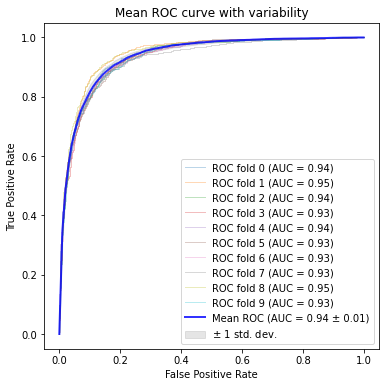

Mean AUC: 0.9359484108648254 ± 0.005780678318558928


In [46]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc, RocCurveDisplay
from sklearn.model_selection import StratifiedKFold
from catboost import CatBoostClassifier

# Cross-validation setup
n_splits = 10
random_state = 217
cv = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=random_state)

# Initialize CatBoost classifier with similar hyperparameters
classifier = CatBoostClassifier(
    iterations=254,  # Equivalent to n_estimators
    depth=5,  # Equivalent to max_depth
    learning_rate=0.12, 
    l2_leaf_reg=3.05,  # Equivalent to reg_lambda
    #boosting_type='Ordered',  # More similar to Dart boosting in XGBoost
    subsample=0.725,  # Keep subsample same as XGBoost
    border_count=80,  # Similar to XGBoost 'hist' method
    scale_pos_weight=4,  # Same class balancing as XGBoost
    random_seed=random_state,
    bagging_temperature=2,
    random_strength=2.0,
    colsample_bylevel=0.9,
    leaf_estimation_method='Gradient',
    verbose=False,  # Silence training logs
    grow_policy='Lossguide'
)

# Lists to store results
tprs = []
aucs = []
mean_fpr = np.linspace(0, 1, 100)
probas_list = []  # Store the probabilities for each cv
IDs = []

fig, ax = plt.subplots(figsize=(6, 6))

# Cross-validation loop
for fold, (train, test) in enumerate(cv.split(X, Y)):
    
    #if fold != 0:
    #    continue  # Only run fold 0 as per original script

    classifier.fit(X[train], Y[train])
    probabilities = classifier.predict_proba(X[test])[:, 1]  # Get probabilities for positive class
    probas_list.append(probabilities)
    IDs.append(meta_T1df_dropped.index[test])
    
    # Compute ROC curve and ROC area
    fpr, tpr, thresholds = roc_curve(Y[test], probabilities)
    viz = RocCurveDisplay(fpr=fpr, tpr=tpr, roc_auc=auc(fpr, tpr), estimator_name=f"ROC fold {fold}")
    viz.plot(ax=ax, alpha=0.3, lw=1, name=f"ROC fold {fold}")
    
    interp_tpr = np.interp(mean_fpr, fpr, tpr)
    interp_tpr[0] = 0.0
    tprs.append(interp_tpr)
    aucs.append(viz.roc_auc)
    print(f"Fold {fold} AUC: {viz.roc_auc}")
    
# Compute mean ROC curve
mean_tpr = np.mean(tprs, axis=0)
mean_tpr[-1] = 1.0
mean_auc = auc(mean_fpr, mean_tpr)
std_auc = np.std(aucs)

ax.plot(
    mean_fpr,
    mean_tpr,
    color="b",
    label=r"Mean ROC (AUC = %0.2f ± %0.2f)" % (mean_auc, std_auc),
    lw=2,
    alpha=0.8,
)

# Plot standard deviation shading
std_tpr = np.std(tprs, axis=0)
tprs_upper = np.minimum(mean_tpr + std_tpr, 1)
tprs_lower = np.maximum(mean_tpr - std_tpr, 0)
ax.fill_between(
    mean_fpr,
    tprs_lower,
    tprs_upper,
    color="grey",
    alpha=0.2,
    label=r"$\pm$ 1 std. dev.",
)

# Final plot settings
ax.set(
    xlabel="False Positive Rate",
    ylabel="True Positive Rate",
    title="Mean ROC curve with variability",
)
ax.legend(loc="lower right")
plt.show()

print(f"Mean AUC: {mean_auc} ± {std_auc}")


# Test on T2 diabetes patients

In [48]:
#retrain final classifier on all samples
random_state=217

classifier_final = xgboost.XGBClassifier(n_estimators=910, random_state=random_state, learning_rate=0.8, max_depth=34, reg_alpha=0,
                                     booster='dart', rate_drop=0.2, subsample=0.6, reg_lambda=0, gamma=0,tree_method='hist')

classifier_final.fit(training_df, testing_df)

# Create XGBClassifier
#classifier_final = xgboost.XGBClassifier()

# Load model parameters from your existing booster
#classifier_final.load_model('/cellar/users/tsears/projects/T1D/XGBoostModels/ALL_NoPCs_199.ubj')



[13:40:08] WARNING: /tmp/abs_40obctay9q/croots/recipe/xgboost-split_1659548945886/work/src/learner.cc:1115: Starting in XGBoost 1.3.0, the default evaluation metric used with the objective 'binary:logistic' was changed from 'error' to 'logloss'. Explicitly set eval_metric if you'd like to restore the old behavior.


XGBClassifier(base_score=0.5, booster='dart', colsample_bylevel=1,
              colsample_bynode=1, colsample_bytree=1, enable_categorical=False,
              gamma=0, gpu_id=-1, importance_type=None,
              interaction_constraints='', learning_rate=0.8, max_delta_step=0,
              max_depth=34, min_child_weight=1, missing=nan,
              monotone_constraints='()', n_estimators=910, n_jobs=8,
              num_parallel_tree=1, predictor='auto', random_state=217,
              rate_drop=0.2, reg_alpha=0, reg_lambda=0, scale_pos_weight=1,
              subsample=0.6, tree_method='hist', validate_parameters=1,
              verbosity=None)

In [49]:
classifier_final.save_model('/cellar/users/tsears/projects/T1D/XGBoostModels/ALL_NoPCs_2025.ubj')

In [53]:
classifier_final.load_model('/cellar/users/tsears/projects/T1D/XGBoostModels/ALL_NoPCs_2025.ubj')


### AUC on T2 Discovery patients

In [32]:
#quick test on T2 patients
T2=pd.read_csv("~/projects/T1D/T2_discovery_df.txt",sep="\t",index_col=0)
T2_test=T2.drop(['id1','id2.1','2','3','SEX','T1D'],axis=1)

T2_test['PC1']=np.nan
T2_test['PC2']=np.nan
T2_test['PC3']=np.nan
T2_test['PC4']=np.nan
T2_test['SEX']=np.nan
T2_test['GoKIND']=np.nan
T2_test['T1DGC']=np.nan
T2_test['GENIEUK']=np.nan
T2_test['DCCT']=np.nan


probas_T2=list(classifier_final.predict_proba(T2_test)[:, 1])

flat_ids = T2['id2.1']
flat_probs = probas_T2

# Create a DataFrame
df = pd.DataFrame({'CV_ID': flat_ids, 'Probability': flat_probs})

In [33]:
#export df
#df.to_csv("/cellar/users/tsears/projects/T1D/tables/delong_ALL_T2D_discovery_noPCs.txt",sep="\t")

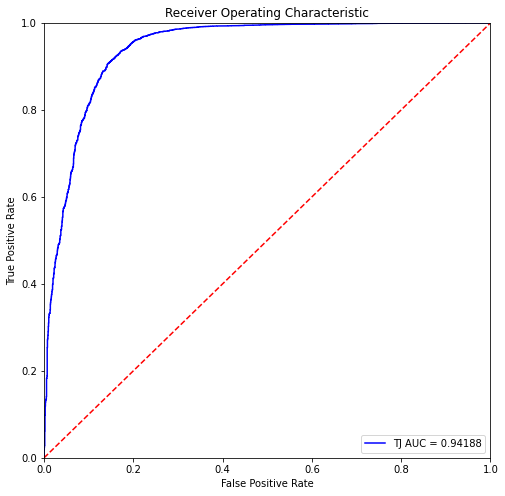

In [34]:
fpr, tpr, threshold = metrics.roc_curve(T2["T1D"],probas_T2,pos_label=2)
roc_auc = metrics.auc(fpr, tpr)

# method I: plt
import matplotlib.pyplot as plt
plt.figure(figsize=(8,8))

plt.title('Receiver Operating Characteristic')
plt.plot(fpr, tpr, 'b', label = 'TJ AUC = %0.5f' % roc_auc)

plt.legend(loc = 'lower right')
plt.plot([0, 1], [0, 1],'r--')
plt.xlim([0, 1])
plt.ylim([0, 1])
plt.ylabel('True Positive Rate')
plt.xlabel('False Positive Rate')
plt.savefig("/cellar/users/tsears/projects/T1D/plots/ALL_T2D_discovery.pdf",bbox_inches = "tight")
plt.show()

### AUC on T2 Discovery patients

In [ ]:
#quick test on T2 patients
T2=pd.read_csv("~/projects/T1D/T2_test_df.txt",sep="\t",index_col=0)
T2_test=T2.drop(['id1','id2.1','2','3','SEX','T1D'],axis=1)

probas_T2=list(classifier_final.predict_proba(T2_test)[:, 1])

flat_ids = T2['id2.1']
flat_probs = probas_T2

# Create a DataFrame
df = pd.DataFrame({'CV_ID': flat_ids, 'Probability': flat_probs})

In [ ]:
#export df
df.to_csv("/cellar/users/tsears/projects/T1D/tables/delong_ALL_T2D_test_noPCs.txt",sep="\t")

In [ ]:
fpr, tpr, threshold = metrics.roc_curve(T2["T1D"],probas_T2,pos_label=2)
roc_auc = metrics.auc(fpr, tpr)

# method I: plt
import matplotlib.pyplot as plt
plt.figure(figsize=(8,8))

plt.title('Receiver Operating Characteristic')
plt.plot(fpr, tpr, 'b', label = 'TJ AUC = %0.5f' % roc_auc)

plt.legend(loc = 'lower right')
plt.plot([0, 1], [0, 1],'r--')
plt.xlim([0, 1])
plt.ylim([0, 1])
plt.ylabel('True Positive Rate')
plt.xlabel('False Positive Rate')
plt.savefig("/cellar/users/tsears/projects/T1D/plots/ALL_T2D_test.pdf",bbox_inches = "tight")
plt.show()

# Test on held-out NPOD cohort

In [54]:
#quick test on T2 patients
T2=pd.read_csv("~/projects/T1D/NPOD_df.txt",sep="\t",index_col=0)
T2_test=T2.drop(['id1','id2.1','2','3','SEX','T1D'],axis=1)

#T2_test['PC1']=np.nan
#T2_test['PC2']=np.nan
#T2_test['PC3']=np.nan
#T2_test['PC4']=np.nan
#T2_test['SEX']=np.nan
#T2_test['GoKIND']=np.nan
#T2_test['T1DGC']=np.nan
#T2_test['GENIEUK']=np.nan
#T2_test['DCCT']=np.nan

probas_T2=list(classifier_final.predict_proba(T2_test)[:, 1])

flat_ids = T2['id2.1']
flat_probs = probas_T2

# Create a DataFrame
df = pd.DataFrame({'CV_ID': flat_ids, 'Probability': flat_probs})

In [55]:
#export df
#df.to_csv("/cellar/users/tsears/projects/T1D/tables/delong_ALL_NPOD_test_noPCs.txt",sep="\t")

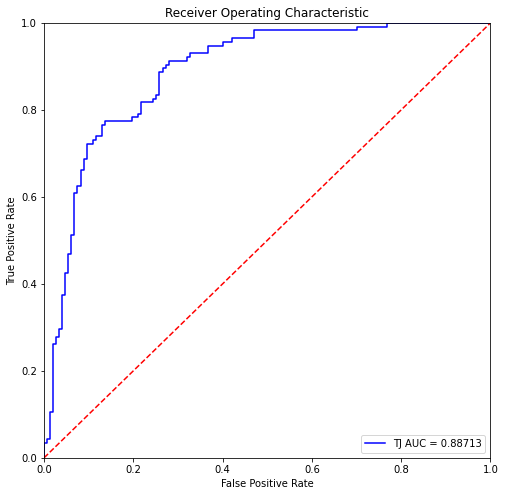

In [56]:
fpr, tpr, threshold = metrics.roc_curve(T2["T1D"],probas_T2,pos_label=2)
roc_auc = metrics.auc(fpr, tpr)

# method I: plt
import matplotlib.pyplot as plt
plt.figure(figsize=(8,8))

plt.title('Receiver Operating Characteristic')
plt.plot(fpr, tpr, 'b', label = 'TJ AUC = %0.5f' % roc_auc)

plt.legend(loc = 'lower right')
plt.plot([0, 1], [0, 1],'r--')
plt.xlim([0, 1])
plt.ylim([0, 1])
plt.ylabel('True Positive Rate')
plt.xlabel('False Positive Rate')
plt.savefig("/cellar/users/tsears/projects/T1D/plots/ALL_NPOD_test.pdf",bbox_inches = "tight")
plt.show()
#8879

# Test on nonDR3DR4

In [ ]:
# load DR3DR4 data, and exclude them from new classifier
T2=pd.read_csv("~/projects/T1D/NonDR3DR4_df.txt",sep="\t",index_col=0)
full_df=T2
T2=T2.drop(['#FID','IID.1','SEX','DISEASE','PC1','PC2','PC3','PC4','T1DGC','DCCT','GENIE_UK','GoKIND'],axis=1)
T2=T2.loc[:,[x in training_df.columns for x in T2.columns]]
T2

In [ ]:
#retrain final classifier on all NON DRD3DR4 samples
classifier_final = xgboost.XGBClassifier(n_estimators=910, random_state=random_state, learning_rate=0.8, max_depth=34, reg_alpha=0,
                                     booster='dart', rate_drop=0.2, subsample=0.6, reg_lambda=0, gamma=0,tree_method='hist')

classifier_final.fit(training_df[[x not in T2.index for x in training_df.index]], testing_df[[x not in T2.index for x in training_df.index]])

In [ ]:
#quick test on T2 patients
probas_T2=list(classifier_final.predict_proba(T2)[:, 1])

flat_ids = T2.index
flat_probs = probas_T2

# Create a DataFrame
df = pd.DataFrame({'CV_ID': flat_ids, 'Probability': flat_probs})

In [ ]:
#export df
df.to_csv("/cellar/users/tsears/projects/T1D/tables/delong_ALL_nonDRD3DR4_noPCs.txt",sep="\t")


In [ ]:
fpr, tpr, threshold = metrics.roc_curve(full_df["DISEASE"],probas_T2,pos_label=2)
roc_auc = metrics.auc(fpr, tpr)

# method I: plt
import matplotlib.pyplot as plt
plt.figure(figsize=(8,8))

plt.title('Receiver Operating Characteristic')
plt.plot(fpr, tpr, 'b', label = 'TJ AUC = %0.5f' % roc_auc)

plt.legend(loc = 'lower right')
plt.plot([0, 1], [0, 1],'r--')
plt.xlim([0, 1])
plt.ylim([0, 1])
plt.ylabel('True Positive Rate')
plt.xlabel('False Positive Rate')
#plt.savefig("/cellar/users/tsears/projects/T1D/plots/ALL_DR3DR4.pdf",bbox_inches = "tight")
plt.show()

### Delong test vs previous performance

In [ ]:
# load in dataset
# merge IDs and probabilities
flat_ids = [item for sublist in IDs for item in sublist]
flat_probs = [item for sublist in probas_list for item in sublist]

# Create a DataFrame
df = pd.DataFrame({'CV_ID': flat_ids, 'Probability': flat_probs})

GRS2=pd.read_csv("/cellar/users/tsears/projects/T1D/ALL5_merged_GRS2_remove_dup_alleles_new_beta_new_11_20_23.txt",sep="\t")
GRS2=GRS2[['FID','sum_All5_nonHLA','Total_sum_HLA','Total_sum','disease']]

# merge with results
delong_export=pd.merge(df,GRS2,left_on="CV_ID",right_on="FID",how="left")
delong_plot=pd.merge(df,GRS2,left_on="CV_ID",right_on="FID")

delong_export.to_csv("/cellar/users/tsears/projects/T1D/delong_ALL_V2_noPCs.txt",sep="\t")

In [ ]:
validation_plot=delong_plot

import sklearn.metrics as metrics
from scipy import stats
import scikit_posthocs as sp
#import pyroc

fpr, tpr, threshold = metrics.roc_curve(validation_plot["disease"],validation_plot["Probability"],pos_label=2)
roc_auc = metrics.auc(fpr, tpr)
fpr1, tpr1, threshold1 = metrics.roc_curve(validation_plot["disease"],validation_plot["Total_sum"],pos_label=2)
roc_auc1 = metrics.auc(fpr1, tpr1)

p_value=0.134#delong_roc_test(validation_plot['disease'], validation_plot['Probability'], validation_plot['sum_All5_nonHLA'])

# method I: plt
import matplotlib.pyplot as plt
plt.figure(figsize=(8,8))

plt.text(0.6, 0.2, f'DeLong Test p-value = {p_value:.3f}', fontsize=12)

plt.title('Receiver Operating Characteristic')
plt.plot(fpr, tpr, 'b', label = 'TJ AUC = %0.5f' % roc_auc)
plt.plot(fpr1, tpr1, 'r', label = 'GRS2 AUC = %0.5f' % roc_auc1)

plt.legend(loc = 'lower right')
plt.plot([0, 1], [0, 1],'r--')
plt.xlim([0, 1])
plt.ylim([0, 1])
plt.ylabel('True Positive Rate')
plt.xlabel('False Positive Rate')
plt.savefig("/cellar/users/tsears/projects/T1D/All_AUC_noPCs.pdf",bbox_inches = "tight")
plt.show()


# Feature importance and interaction

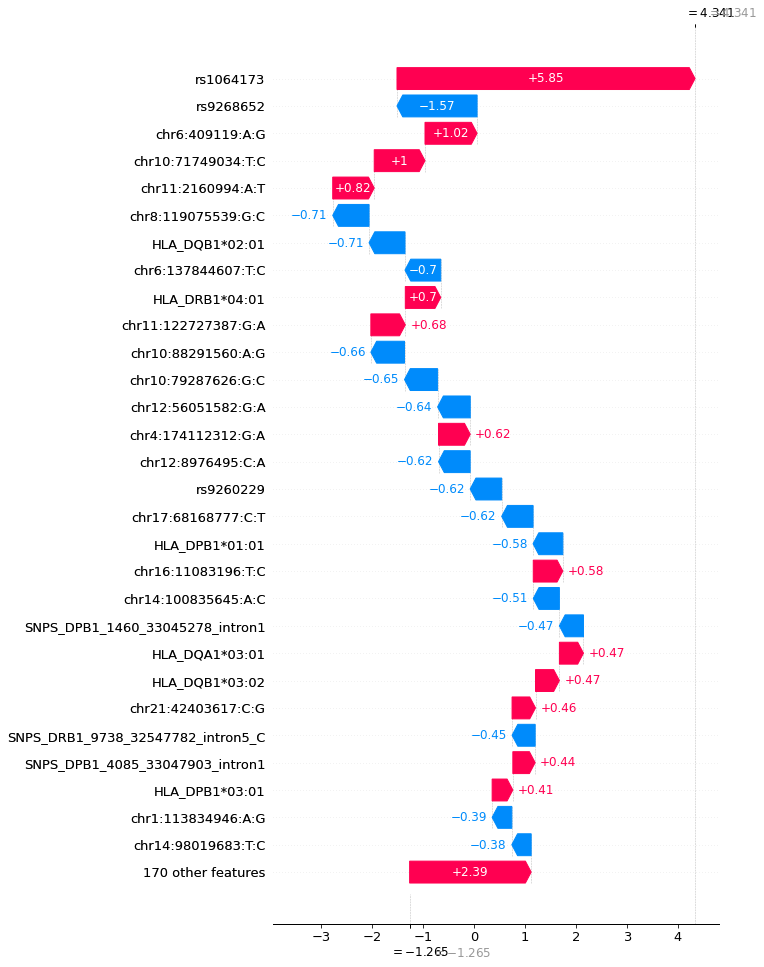

In [48]:
shap.plots._waterfall.waterfall_legacy(explainer.expected_value,shap_values[1535], max_display=30,feature_names = X.columns,show=False)
plt.savefig("/cellar/users/tsears/projects/T1D/plots/All_WTCCC1-T1D-A_WTCCC168357_waterfall.pdf",bbox_inches='tight')
